# Лабораторная работа №1. Разведочный анализ данных

**Датасет:** Car Price Prediction  
**Источник:** https://www.kaggle.com/datasets/vijayaadithyanvg/car-price-predictionused-cars/data  
**Тип задачи:** регрессия  
**Целевая переменная:** `Selling_Price`

Цель работы — изучить структуру и качество данных, выполнить очистку, исследовать связи признаков
с целевой переменной, сформировать полезный новый признак и сохранить очищенную выборку
для следующих лабораторных работ.

> Файл исходных данных не хранится в Git. Перед запуском необходимо поместить CSV-файл
> в `data/car_data.csv`.

# 1. Загрузка и знакомство с данными

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Notebook корректно работает как при запуске из корня проекта,
# так и при запуске непосредственно из директории eda.
cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (p for p in root_candidates if (p / "data" / "car_data.csv").exists()),
    cwd.parent
)

DATA_PATH = PROJECT_ROOT / "data" / "car_data.csv"
EDA_DIR = PROJECT_ROOT / "eda"
CLEAN_PATH = PROJECT_ROOT / "data" / "clean_data.pkl"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл {DATA_PATH}. "
        "Скачайте датасет и сохраните его как data/car_data.csv."
    )

EDA_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
print(f"Размер исходной выборки: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
display(df.dtypes.rename("dtype").to_frame())

print("\nПропущенные значения:")
display(df.isna().sum().rename("missing").to_frame())

print("Полные дубликаты:", int(df.duplicated().sum()))

print("\nОсновные статистики:")
display(df.describe(include="all").T)

Размер исходной выборки: 301 строк, 9 столбцов

Типы данных:


,dtype
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Driven_kms,int64
Fuel_Type,object
Selling_type,object
Transmission,object
Owner,int64



Пропущенные значения:


,missing
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


Полные дубликаты: 2

Основные статистики:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


### Типы признаков

- **Целевая переменная:** `Selling_Price`.
- **Числовые признаки:** `Year`, `Present_Price`, `Driven_kms`.
- **Дискретный числовой признак:** `Owner`.
- **Категориальные признаки:** `Car_Name`, `Fuel_Type`, `Selling_type`, `Transmission`.

`Car_Name` имеет большое число уникальных значений, поэтому при дальнейшем построении модели
этот признак потребует аккуратного кодирования.

In [3]:
categorical_cols = ["Car_Name", "Fuel_Type", "Selling_type", "Transmission"]

category_summary = pd.DataFrame({
    "unique_values": [df[col].nunique() for col in categorical_cols],
    "most_frequent": [df[col].mode().iloc[0] for col in categorical_cols]
}, index=categorical_cols)

display(category_summary)

for col in ["Fuel_Type", "Selling_type", "Transmission", "Owner"]:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False).to_frame("count"))

,unique_values,most_frequent
Car_Name,98,city
Fuel_Type,3,Petrol
Selling_type,2,Dealer
Transmission,2,Manual



Fuel_Type:


,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2



Selling_type:


,count
Selling_type,
Dealer,195
Individual,106



Transmission:


,count
Transmission,
Manual,261
Automatic,40



Owner:


,count
Owner,
0,290
1,10
3,1


**Промежуточный вывод.** Исходная выборка содержит 301 объект и 9 столбцов.
Пропущенных значений нет. Найдены 2 полных дубликата.
В категориальных признаках присутствует дисбаланс: например, категория `CNG`
встречается только два раза, поэтому выводы по малочисленным категориям необходимо делать осторожно.

# 2. Очистка данных

In [4]:
n_before = len(df)

# 1. Удаляем только полные дубликаты.
df = df.drop_duplicates().copy()

# 2. Явно задаем тип category для категориальных признаков.
for col in categorical_cols:
    df[col] = df[col].astype("category")

# 3. Проверяем базовую валидность числовых значений.
validity_checks = pd.Series({
    "Selling_Price <= 0": int((df["Selling_Price"] <= 0).sum()),
    "Present_Price <= 0": int((df["Present_Price"] <= 0).sum()),
    "Selling_Price > Present_Price": int((df["Selling_Price"] > df["Present_Price"]).sum()),
    "Driven_kms < 0": int((df["Driven_kms"] < 0).sum()),
    "Owner < 0": int((df["Owner"] < 0).sum()),
}, name="invalid_rows")

print("Удалено полных дубликатов:", n_before - len(df))
print("Размер после удаления дубликатов:", df.shape)
print("Пропусков после очистки:", int(df.isna().sum().sum()))
display(validity_checks.to_frame())

Удалено полных дубликатов: 2
Размер после удаления дубликатов: (299, 9)
Пропусков после очистки: 0


,invalid_rows
Selling_Price <= 0,0
Present_Price <= 0,0
Selling_Price > Present_Price,0
Driven_kms < 0,0
Owner < 0,0


**Вывод по очистке.** Удалены 2 полных дубликата. Пропусков и явно невалидных значений
по проверенным условиям не обнаружено.

Экстремальные значения (`Driven_kms` до 500000, высокая цена отдельных автомобилей)
не удалялись автоматически: статистический выброс не обязательно является ошибкой.
Без предметного основания удаление таких объектов может исказить выборку.

## Создание нового признака

In [5]:
# В датасете нет даты продажи, поэтому не вводим искусственный "текущий год".
# Вместо этого строим относительный возраст относительно самого нового года в выборке.
reference_year = int(df["Year"].max())
df["Car_Age"] = reference_year - df["Year"]

print("Самый новый год в выборке:", reference_year)
display(df[["Year", "Car_Age"]].head())

Самый новый год в выборке: 2018


,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4


Создан признак `Car_Age` — относительный возраст автомобиля внутри выборки.
Чем больше `Car_Age`, тем старше автомобиль. Использование максимального года из самого датасета
позволяет не делать неподтвержденных предположений о дате продажи.

# 3. Анализ признаков для модели

## График 1. Распределение целевой переменной

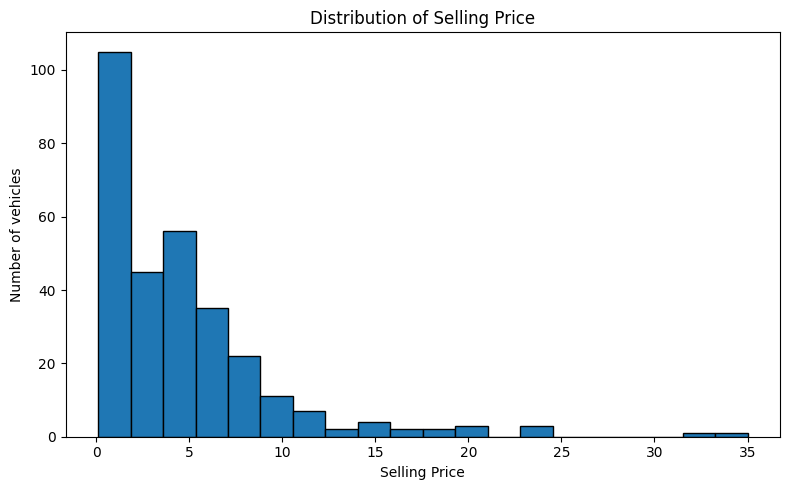

Mean: 4.59
Median: 3.51


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Selling_Price"], bins=20, edgecolor="black")
ax.set_title("Distribution of Selling Price")
ax.set_xlabel("Selling Price")
ax.set_ylabel("Number of vehicles")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph1_selling_price_distribution.png", dpi=150)
plt.show()

print("Mean:", round(df["Selling_Price"].mean(), 2))
print("Median:", round(df["Selling_Price"].median(), 2))

**Вывод:** распределение `Selling_Price` правосторонне асимметрично:
среднее выше медианы из-за небольшого числа дорогих объектов.
Следовательно, при дальнейшем моделировании важно учитывать неоднородность распределения цели.

## График 2. Связь текущей цены и цены продажи

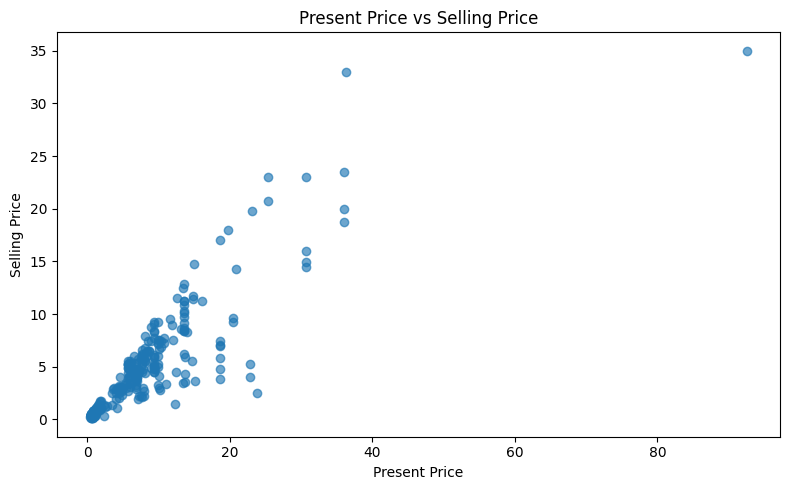

Correlation: 0.876


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Present_Price"], df["Selling_Price"], alpha=0.65)
ax.set_title("Present Price vs Selling Price")
ax.set_xlabel("Present Price")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph2_present_vs_selling.png", dpi=150)
plt.show()

corr_present = df["Present_Price"].corr(df["Selling_Price"])
print("Correlation:", round(corr_present, 3))

**Вывод:** между `Present_Price` и `Selling_Price` наблюдается сильная положительная линейная связь
(корреляция около 0.88). `Present_Price` является одним из наиболее информативных признаков
для будущей модели.

## График 3. Цена продажи по типу топлива

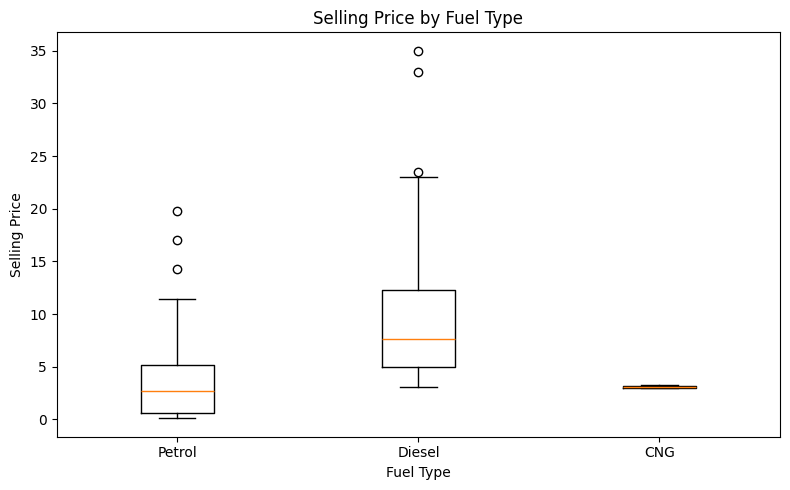

,count,mean,median
Fuel_Type,,,
CNG,2,3.10,3.10
Diesel,58,10.10,7.60
Petrol,239,3.26,2.65


In [8]:
fuel_order = ["Petrol", "Diesel", "CNG"]
fuel_data = [
    df.loc[df["Fuel_Type"] == fuel, "Selling_Price"]
    for fuel in fuel_order
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(fuel_data, tick_labels=fuel_order)
ax.set_title("Selling Price by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph3_fuel_type_boxplot.png", dpi=150)
plt.show()

display(
    df.groupby("Fuel_Type", observed=True)["Selling_Price"]
      .agg(["count", "mean", "median"])
      .round(2)
)

**Вывод:** в этой выборке дизельные транспортные средства имеют более высокую типичную цену продажи,
чем бензиновые. Для `CNG` имеется только 2 наблюдения, поэтому по этой категории нельзя делать
устойчивые выводы. Различие между группами не интерпретируется как причинный эффект типа топлива.

## График 4. Цена продажи по типу коробки передач

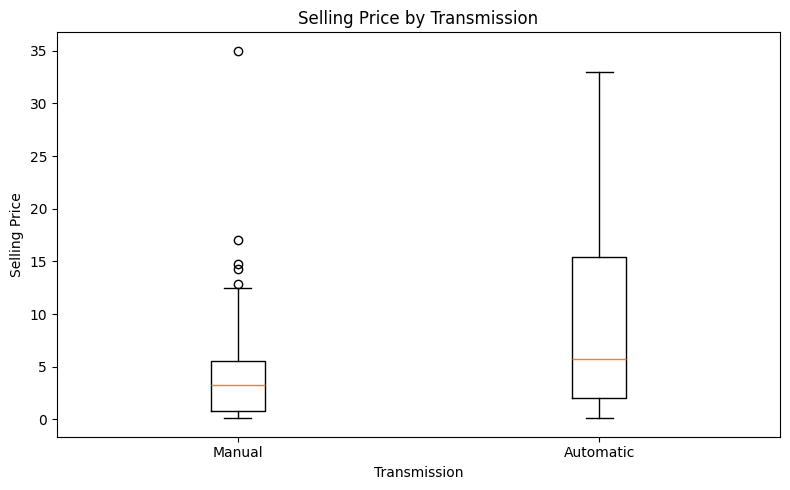

,count,mean,median
Transmission,,,
Automatic,39,9.07,5.75
Manual,260,3.92,3.25


In [9]:
transmission_order = ["Manual", "Automatic"]
transmission_data = [
    df.loc[df["Transmission"] == transmission, "Selling_Price"]
    for transmission in transmission_order
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(transmission_data, tick_labels=transmission_order)
ax.set_title("Selling Price by Transmission")
ax.set_xlabel("Transmission")
ax.set_ylabel("Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph4_transmission_boxplot.png", dpi=150)
plt.show()

display(
    df.groupby("Transmission", observed=True)["Selling_Price"]
      .agg(["count", "mean", "median"])
      .round(2)
)

**Вывод:** в данной выборке медианная цена объектов с автоматической коробкой выше,
чем у объектов с механической коробкой. При этом группа `Automatic` существенно меньше,
поэтому результат следует интерпретировать с учетом размера групп.

## График 5. Цена по типу продавца

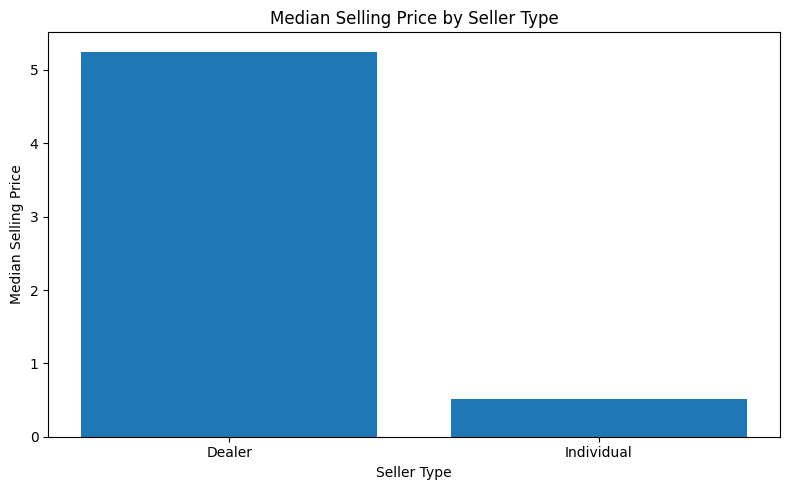

,count,mean,median
Selling_type,,,
Dealer,193,6.63,5.25
Individual,106,0.87,0.52


In [10]:
seller_stats = (
    df.groupby("Selling_type", observed=True)["Selling_Price"]
      .agg(["count", "mean", "median"])
      .round(2)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seller_stats.index, seller_stats["median"])
ax.set_title("Median Selling Price by Seller Type")
ax.set_xlabel("Seller Type")
ax.set_ylabel("Median Selling Price")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph5_seller_type_median.png", dpi=150)
plt.show()

display(seller_stats)

**Вывод:** медианная цена в группе `Dealer` выше, чем в группе `Individual`.
Это может быть связано с различием состава транспортных средств между группами,
поэтому сам по себе тип продавца не доказывает причинного влияния на цену,
но может быть полезным признаком модели.

## График 6. Матрица корреляций

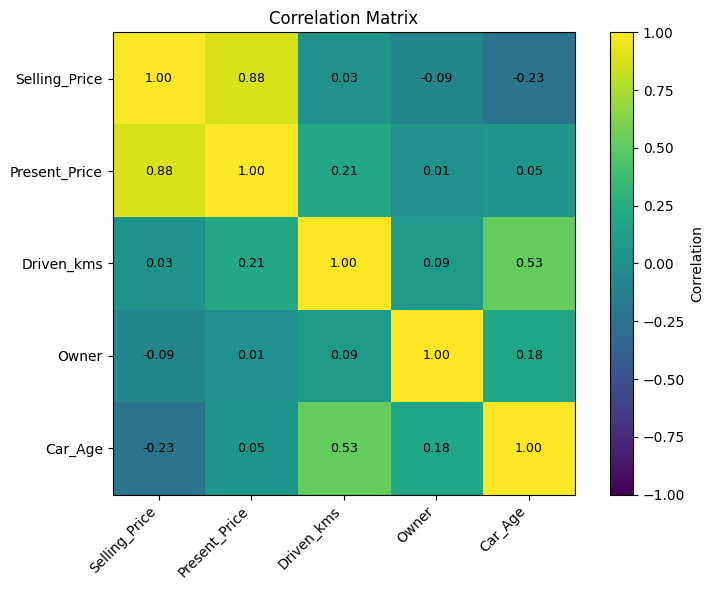

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age
Selling_Price,1.000,0.876,0.029,-0.088,-0.234
Present_Price,0.876,1.000,0.205,0.010,0.053
Driven_kms,0.029,0.205,1.000,0.089,0.526
Owner,-0.088,0.010,0.089,1.000,0.182
Car_Age,-0.234,0.053,0.526,0.182,1.000


In [11]:
# Year и Car_Age одновременно не включаем:
# эти признаки линейно зависимы друг от друга по определению.
corr_cols = ["Selling_Price", "Present_Price", "Driven_kms", "Owner", "Car_Age"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
fig.tight_layout()
fig.savefig(EDA_DIR / "graph6_correlation_matrix.png", dpi=150)
plt.show()

display(corr.round(3))

**Вывод:** самая сильная линейная связь с `Selling_Price` наблюдается у `Present_Price`.
`Car_Age` имеет отрицательную связь с ценой: более старые объекты в среднем дешевле.
Линейная связь `Driven_kms` с ценой слабая, поэтому его эффект может проявляться
во взаимодействии с другими признаками.

## График 7. Интерактивный график Bokeh

In [12]:
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
from bokeh.resources import INLINE

def make_interactive_plot():
    source = ColumnDataSource(df)
    p = figure(
        width=900,
        height=550,
        title="Interactive: Present Price vs Selling Price",
        x_axis_label="Present Price",
        y_axis_label="Selling Price",
        tools="pan,wheel_zoom,box_zoom,reset,save"
    )
    p.scatter(
        x="Present_Price",
        y="Selling_Price",
        source=source,
        size=7,
        alpha=0.65
    )
    p.add_tools(HoverTool(tooltips=[
        ("Car", "@Car_Name"),
        ("Year", "@Year"),
        ("Present price", "@Present_Price"),
        ("Selling price", "@Selling_Price"),
        ("Driven kms", "@Driven_kms"),
        ("Fuel", "@Fuel_Type"),
        ("Transmission", "@Transmission"),
    ]))
    return p

# Сохраняем отдельный автономный HTML-файл.
interactive_path = EDA_DIR / "graph7_interactive.html"
output_file(interactive_path, title="Car Price Interactive EDA")
save(make_interactive_plot(), resources=INLINE)

# Для отображения в Jupyter создаем отдельный объект,
# чтобы одна и та же Bokeh-модель не принадлежала двум документам.
output_notebook(resources=INLINE)
show(make_interactive_plot())

print("Интерактивный график сохранен:", interactive_path)

Интерактивный график сохранен: /mnt/data/lab1_car_price/eda/graph7_interactive.html


**Вывод:** интерактивный scatter plot позволяет исследовать отдельные объекты,
увеличивать область графика и при наведении смотреть модель, год, пробег,
тип топлива и трансмиссии. Он подтверждает общую положительную связь
между `Present_Price` и `Selling_Price`.

# 4. Сохранение финального датасета

In [13]:
df.to_pickle(CLEAN_PATH)

print("Очищенный датасет сохранен:", CLEAN_PATH)
print("Итоговый размер:", df.shape)
print("\nТипы данных финальной выборки:")
df.info()

Очищенный датасет сохранен: /mnt/data/lab1_car_price/data/clean_data.pkl
Итоговый размер: (299, 10)

Типы данных финальной выборки:
<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       299 non-null    category
 1   Year           299 non-null    int64   
 2   Selling_Price  299 non-null    float64 
 3   Present_Price  299 non-null    float64 
 4   Driven_kms     299 non-null    int64   
 5   Fuel_Type      299 non-null    category
 6   Selling_type   299 non-null    category
 7   Transmission   299 non-null    category
 8   Owner          299 non-null    int64   
 9   Car_Age        299 non-null    int64   
dtypes: category(4), float64(2), int64(4)
memory usage: 20.7 KB


In [14]:
# Контрольная проверка сохраненного файла.
check_df = pd.read_pickle(CLEAN_PATH)

assert check_df.shape == df.shape
assert check_df.isna().sum().sum() == 0
assert check_df.duplicated().sum() == 0

print("Проверка сохраненного датасета пройдена.")

Проверка сохраненного датасета пройдена.


# 5. Выводы после EDA

В ходе работы:

- загружена рекомендованная выборка **Car Price Prediction**: 301 объект, 9 исходных столбцов;
- определена задача **регрессии**, целевая переменная — `Selling_Price`;
- выделены числовые, дискретные и категориальные признаки;
- проверены типы данных, описательная статистика, пропуски и полные дубликаты;
- пропущенных значений не обнаружено;
- удалены **2 полных дубликата**, после очистки осталось 299 объектов;
- выполнены проверки базовой валидности цены, пробега и числа владельцев;
- экстремальные, но допустимые значения не удалялись без предметного основания;
- категориальные признаки приведены к типу `category`;
- создан новый признак `Car_Age`;
- построено **6 статических графиков и 1 интерактивный график Bokeh**;
- наиболее сильная линейная связь с целью обнаружена у `Present_Price`
  (корреляция около **0.88**);
- выявлены различия распределения цены между типами топлива, трансмиссии и продавца,
  при этом выводы сделаны с учетом дисбаланса размеров групп;
- очищенная выборка сохранена в `data/clean_data.pkl` для следующих лабораторных работ.